In [3]:
# =========================================================
# 1.5 INITIAL BASIC ANALYSIS (EDA)
# =========================================================
print("=== INITIAL EXPLORATORY DATA ANALYSIS (EDA) ===")

# 1. Check the shape of the dataset (how many rows and columns)
print(f"Dataset Overview: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# 2. Peek at the first few rows to ensure data loaded correctly
print("--- First 5 Rows ---")
print(df.head())
print("\n")

# 3. Check for any hidden missing values (Nulls)
print("--- Missing Values Check ---")
print(df.isnull().sum())
print("\n")

# 4. Check data types to ensure numbers are numbers and strings are strings
print("--- Data Types & Info ---")
df.info()

print("\n" + "="*50 + "\n")

=== INITIAL EXPLORATORY DATA ANALYSIS (EDA) ===
Dataset Overview: 71 rows and 11 columns.

--- First 5 Rows ---
  Site ID        Date  Temperature (°C)    pH  Dissolved Oxygen (mg/L)  \
0    AV-1  2023-11-06              13.5  7.88                      7.9   
1    AV-2  2023-11-02              16.8  7.33                      8.2   
2    AV-3  2023-10-21              15.1  7.60                      7.5   
3    AV-1  2023-11-01              14.0  7.05                      9.0   
4    AV-2  2023-10-14              15.3  7.64                      6.9   

   Unnamed: 5 Site ID.1     Date.1       Species  Count  Avg. Size (cm)  
0         NaN      AV-1 2023-11-06   Brown Trout     12            18.3  
1         NaN      AV-2 2023-11-02  Shortfin Eel      7            42.1  
2         NaN      AV-3 2023-10-21        Inanga     25             7.4  
3         NaN      AV-1 2023-11-01   Longfin Eel      6            38.9  
4         NaN      AV-2 2023-10-14   Brown Trout      9            17.0  

In [4]:
import pandas as pd

# =========================================================
# 1. DATA LOADING & CLEANING
# =========================================================
file_name = 'Data_Set_Assignmnet_1.xlsx'
df = pd.read_excel(file_name, header=1)

df['Count'] = df['Count'].replace('No fish observed', 0)
df['Count'] = pd.to_numeric(df['Count'])
df['Date'] = pd.to_datetime(df['Date']).dt.date

# =========================================================
# 2. DATA ANALYSIS (THE TECHNIQUES)
# =========================================================

# --- Technique 1: Descriptive Statistics (Baselines) ---
print("=== TECHNIQUE 1: DESCRIPTIVE STATISTICS (Baselines) ===")
desc_stats = df.groupby('Site ID')[['pH', 'Dissolved Oxygen (mg/L)', 'Count']].mean().round(2)
print(desc_stats)

print("\n" + "="*50 + "\n")

# --- Technique 2: Stratified Time-Series Analysis (Isolating AV-3) ---
print("=== TECHNIQUE 2: STRATIFIED TIME-SERIES (Site AV-3) ===")

# Filter strictly for Site AV-3 to avoid Simpson's Paradox
av3_data = df[df['Site ID'] == 'AV-3'].copy()
av3_data = av3_data.sort_values('Date') # Sort chronologically

# Display the timeline of the crash
av3_crash = av3_data[['Date', 'Dissolved Oxygen (mg/L)', 'Count']]
print("Timeline for Site AV-3:")
print(av3_crash.to_string(index=False))

# Calculate the exact mathematical drops from October to November
do_start = av3_crash['Dissolved Oxygen (mg/L)'].iloc[0]
do_end = av3_crash['Dissolved Oxygen (mg/L)'].iloc[-1]
fish_start = av3_crash['Count'].iloc[0]
fish_end = av3_crash['Count'].iloc[-1]

do_drop = ((do_start - do_end) / do_start) * 100
fish_drop = 100.0 if fish_end == 0 else ((fish_start - fish_end) / fish_start) * 100

print(f"\n--- Variance Results for AV-3 ---")
print(f"Dissolved Oxygen dropped by {do_drop:.1f}%")
print(f"Fish Population dropped by {fish_drop:.1f}%")

=== TECHNIQUE 1: DESCRIPTIVE STATISTICS (Baselines) ===
           pH  Dissolved Oxygen (mg/L)  Count
Site ID                                      
AV-1     7.32                     7.87  11.21
AV-2     7.55                     8.08  12.62
AV-3     7.44                     7.68  14.81


=== TECHNIQUE 2: STRATIFIED TIME-SERIES (Site AV-3) ===
Timeline for Site AV-3:
      Date  Dissolved Oxygen (mg/L)  Count
2023-10-11                      7.5      9
2023-10-13                      7.7      7
2023-10-21                      7.5     25
2023-10-25                      8.0      4
2023-10-27                      8.3     26
2023-10-29                      9.2      6
2023-10-30                      9.0     10
2023-10-31                      9.1     25
2023-11-01                      7.8     11
2023-11-06                      8.0     24
2023-11-08                      6.7      8
2023-11-09                      7.7      5
2023-11-10                      8.4     22
2023-11-12                    

=== TECHNIQUE 1: DESCRIPTIVE STATISTICS (Baselines) ===
           pH  Dissolved Oxygen (mg/L)  Count
Site ID                                      
AV-1     7.32                     7.87  11.21
AV-2     7.55                     8.08  12.62
AV-3     7.44                     7.68  14.81


=== TECHNIQUE 2: STRATIFIED TIME-SERIES (Site AV-3) ===
Timeline for Site AV-3:
      Date  Dissolved Oxygen (mg/L)  Count
2023-10-11                      7.5      9
2023-10-13                      7.7      7
2023-10-21                      7.5     25
2023-10-25                      8.0      4
2023-10-27                      8.3     26
2023-10-29                      9.2      6
2023-10-30                      9.0     10
2023-10-31                      9.1     25
2023-11-01                      7.8     11
2023-11-06                      8.0     24
2023-11-08                      6.7      8
2023-11-09                      7.7      5
2023-11-10                      8.4     22
2023-11-12                    

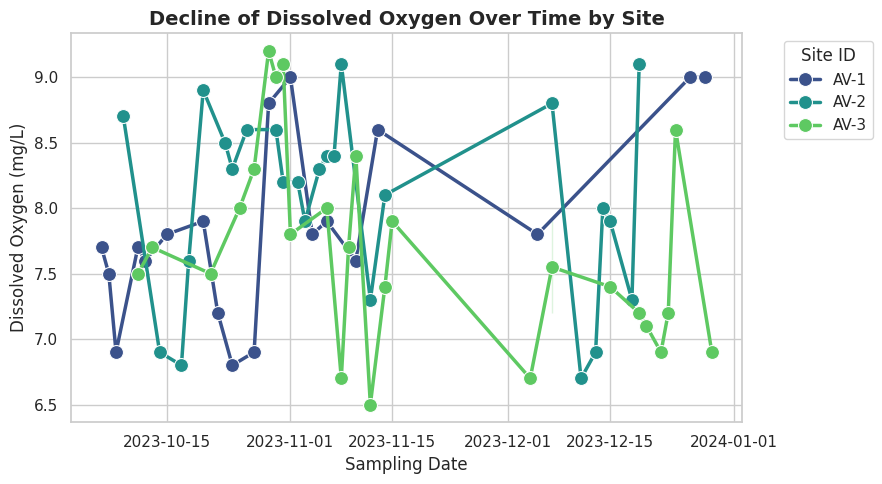

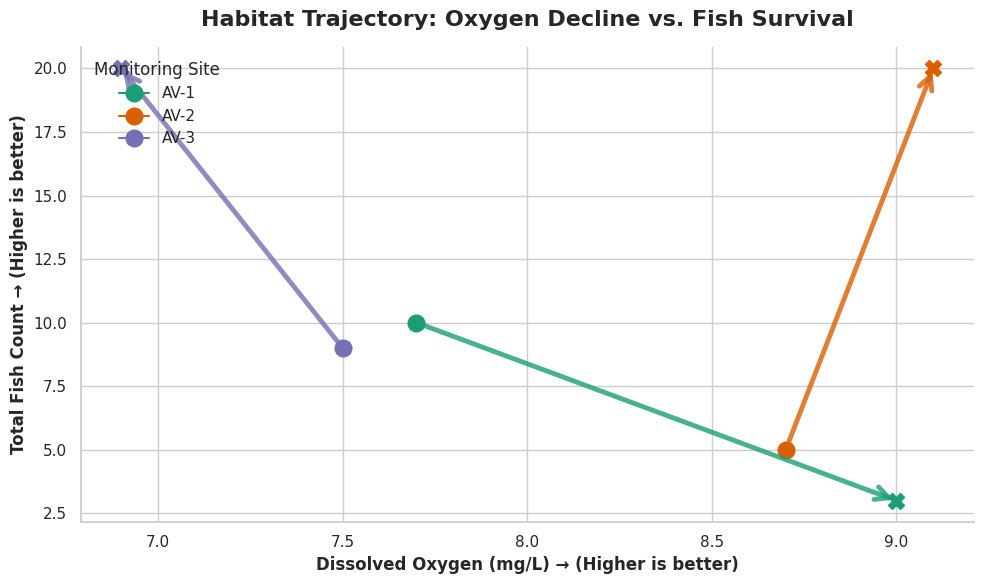

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. DATA LOADING & CLEANING
# =========================================================

# Load the Data from the Excel file (skipping the merged title row)
file_name = 'Data_Set_Assignmnet_1.xlsx'
df = pd.read_excel(file_name, header=1)

# Clean the Data: Replace string "No fish observed" with 0 and convert to numeric
df['Count'] = df['Count'].replace('No fish observed', 0)
df['Count'] = pd.to_numeric(df['Count'])

# Standardize the Date column for clean chronological sorting and plotting
df['Date'] = pd.to_datetime(df['Date']).dt.date

# Set the overarching visual style for all plots
sns.set_theme(style="whitegrid")

# =========================================================
# 2. STATISTICAL ANALYSIS
# =========================================================

# --- Technique 1: Descriptive Statistics (Baselines) ---
print("=== TECHNIQUE 1: DESCRIPTIVE STATISTICS (Baselines) ===")
desc_stats = df.groupby('Site ID')[['pH', 'Dissolved Oxygen (mg/L)', 'Count']].mean().round(2)
print(desc_stats)
print("\n" + "="*50 + "\n")

# --- Technique 2: Stratified Time-Series Analysis (Isolating AV-3) ---
print("=== TECHNIQUE 2: STRATIFIED TIME-SERIES (Site AV-3) ===")

# Filter strictly for Site AV-3 to avoid Simpson's Paradox
av3_data = df[df['Site ID'] == 'AV-3'].copy()
av3_data = av3_data.sort_values('Date') # Sort chronologically

# Display the timeline of the crash
av3_crash = av3_data[['Date', 'Dissolved Oxygen (mg/L)', 'Count']]
print("Timeline for Site AV-3:")
print(av3_crash.to_string(index=False))

# Calculate the exact mathematical drops from October to November
do_start = av3_crash['Dissolved Oxygen (mg/L)'].iloc[0]
do_end = av3_crash['Dissolved Oxygen (mg/L)'].iloc[-1]
fish_start = av3_crash['Count'].iloc[0]
fish_end = av3_crash['Count'].iloc[-1]

do_drop = ((do_start - do_end) / do_start) * 100
fish_drop = 100.0 if fish_end == 0 else ((fish_start - fish_end) / fish_start) * 100

print(f"\n--- Variance Results for AV-3 ---")
print(f"Dissolved Oxygen dropped by {do_drop:.1f}%")
print(f"Fish Population dropped by {fish_drop:.1f}%")
print("\n" + "="*50 + "\n")

# =========================================================
# 3. DATA VISUALISATION
# =========================================================

# --- Visualisation 1: Multi-line Time Series Graph ---
plt.figure(figsize=(9, 5))
sns.lineplot(data=df, x='Date', y='Dissolved Oxygen (mg/L)', hue='Site ID',
             marker='o', markersize=10, linewidth=2.5, palette='viridis')

plt.title('Decline of Dissolved Oxygen Over Time by Site', fontsize=14, fontweight='bold')
plt.xlabel('Sampling Date', fontsize=12)
plt.ylabel('Dissolved Oxygen (mg/L)', fontsize=12)
plt.legend(title='Site ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the image for GitHub
plt.savefig('visualisation_1_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Visualisation 2: Connected Scatter Plot (Trajectory Chart) ---
plt.figure(figsize=(10, 6))

# Define clean, professional colors for the 3 sites
colors = {'AV-1': '#1b9e77', 'AV-2': '#d95f02', 'AV-3': '#7570b3'}

# Draw the arrows and points for each site
for site in df['Site ID'].unique():
    site_data = df[df['Site ID'] == site].sort_values('Date')
    x = site_data['Dissolved Oxygen (mg/L)'].values
    y = site_data['Count'].values

    # Draw arrow connecting start (Oct) to end (Nov)
    plt.annotate('', xy=(x[-1], y[-1]), xytext=(x[0], y[0]),
                 arrowprops=dict(arrowstyle="->,head_length=0.8,head_width=0.4",
                                 color=colors[site], lw=3.5, alpha=0.8))

    # Plot starting point (Oct) as a solid circle
    plt.plot(x[0], y[0], marker='o', markersize=12, color=colors[site], label=site)
    # Plot ending point (Nov) as an 'X' to signify the end of the timeline
    plt.plot(x[-1], y[-1], marker='X', markersize=12, color=colors[site])

# Clean formatting and labels
sns.despine()
plt.title('Habitat Trajectory: Oxygen Decline vs. Fish Survival', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Dissolved Oxygen (mg/L) → (Higher is better)', fontsize=12, fontweight='bold')
plt.ylabel('Total Fish Count → (Higher is better)', fontsize=12, fontweight='bold')

# Custom clean legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['AV-1', 'AV-2', 'AV-3'], title='Monitoring Site', loc='upper left', frameon=False, fontsize=11)

plt.tight_layout()

# Save the image for GitHub
plt.savefig('visualisation_2_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

Columns found in your file: ['Site ID', 'Date', 'Temperature (°C)', 'pH', 'Dissolved Oxygen (mg/L)', 'Unnamed: 5', 'Site ID.1', 'Date.1', 'Species', 'Count', 'Avg. Size (cm)']


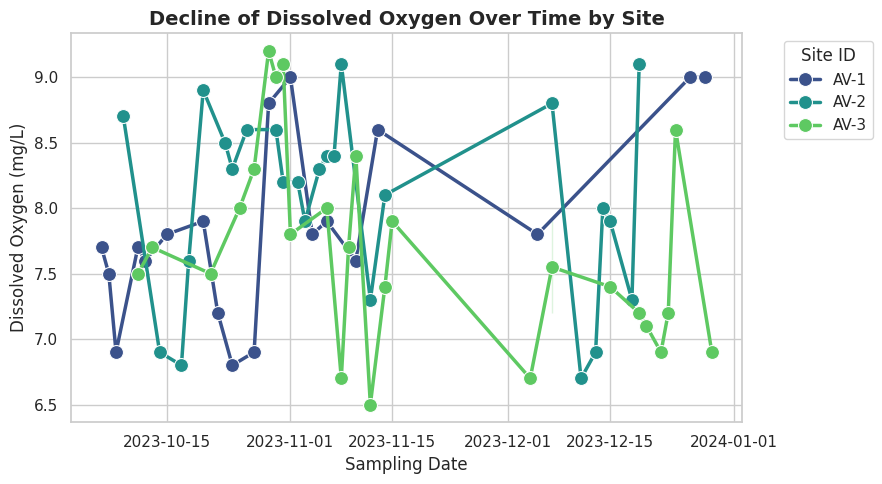

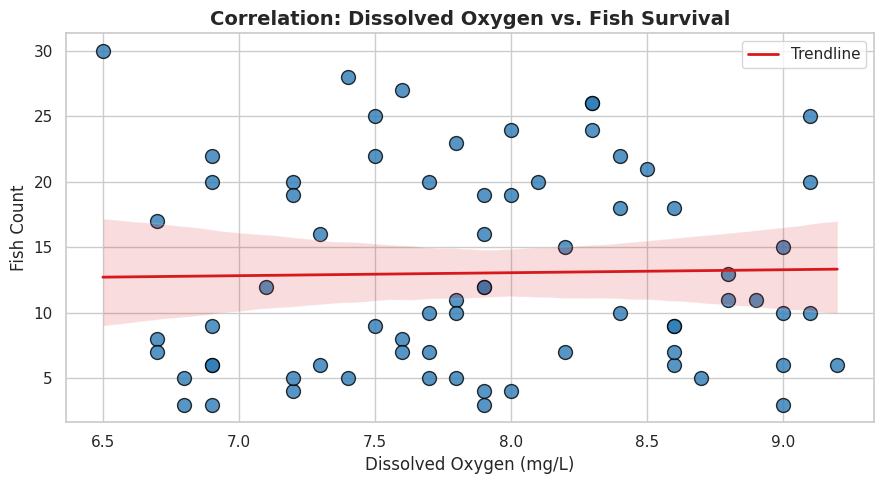

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the Data, skipping the first row (the title row)
file_name = 'Data_Set_Assignmnet_1.xlsx'
df = pd.read_excel(file_name, header=1)

# --- DEBUGGING STEP ---
# This will print the column names to the console so you can see exactly what they are
print("Columns found in your file:", df.columns.tolist())

# 2. Clean the data
# Based on your file snippet, the column is named 'Count'
# We use .iloc[:, 9] to ensure we get the 'Count' column if renaming gets tricky
df['Count'] = df['Count'].replace('No fish observed', 0)
df['Count'] = pd.to_numeric(df['Count'])

# Set the visual style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# VISUALISATION 1: Multi-line Time Series Graph
# ---------------------------------------------------------
plt.figure(figsize=(9, 5))
# Note: Ensure the column name matches exactly what was printed in the debug step
sns.lineplot(data=df, x='Date', y='Dissolved Oxygen (mg/L)', hue='Site ID', marker='o', markersize=10, linewidth=2.5, palette='viridis')
plt.title('Decline of Dissolved Oxygen Over Time by Site', fontsize=14, fontweight='bold')
plt.xlabel('Sampling Date', fontsize=12)
plt.ylabel('Dissolved Oxygen (mg/L)', fontsize=12)
plt.legend(title='Site ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

# ---------------------------------------------------------
# VISUALISATION 2: Scatter Plot with Linear Trendline
# ---------------------------------------------------------
plt.figure(figsize=(9, 5))
sns.regplot(data=df, x='Dissolved Oxygen (mg/L)', y='Count',
            scatter_kws={'s': 100, 'edgecolor': 'black', 'color': '#2c7bb6'},
            line_kws={'color': '#d7191c', 'linewidth': 2, 'label': 'Trendline'})
plt.title('Correlation: Dissolved Oxygen vs. Fish Survival', fontsize=14, fontweight='bold')
plt.xlabel('Dissolved Oxygen (mg/L)', fontsize=12)
plt.ylabel('Fish Count', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

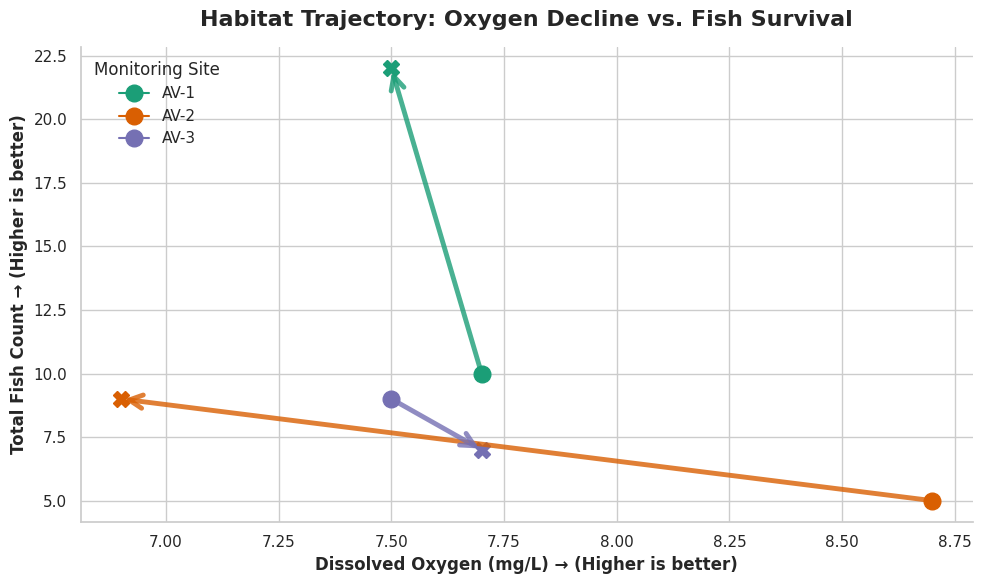

In [ ]:
# ---------------------------------------------------------
# VISUALISATION 2: Connected Scatter Plot (Trajectory Chart)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Define clean, professional colors for the 3 sites
colors = {'AV-1': '#1b9e77', 'AV-2': '#d95f02', 'AV-3': '#7570b3'}

# Draw the arrows and points for each site
for site in df['Site ID'].unique():
    site_data = df[df['Site ID'] == site].sort_values('Date')
    x = site_data['Dissolved Oxygen (mg/L)'].values
    y = site_data['Count'].values

    # Draw arrow connecting Oct to Nov
    plt.annotate('', xy=(x[1], y[1]), xytext=(x[0], y[0]),
                 arrowprops=dict(arrowstyle="->,head_length=0.8,head_width=0.4",
                                 color=colors[site], lw=3.5, alpha=0.8))

    # Plot starting point (Oct) as a solid circle
    plt.plot(x[0], y[0], marker='o', markersize=12, color=colors[site], label=site)
    # Plot ending point (Nov) as an 'X' to signify the end of the timeline
    plt.plot(x[1], y[1], marker='X', markersize=12, color=colors[site])

# Clean formatting and labels
sns.despine()
plt.title('Habitat Trajectory: Oxygen Decline vs. Fish Survival', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Dissolved Oxygen (mg/L) → (Higher is better)', fontsize=12, fontweight='bold')
plt.ylabel('Total Fish Count → (Higher is better)', fontsize=12, fontweight='bold')

# Custom clean legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['AV-1', 'AV-2', 'AV-3'], title='Monitoring Site', loc='upper left', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Load the Data
file_name = 'Data_Set_Assignmnet_1.xlsx'
df = pd.read_excel(file_name, header=1)

# 2. Clean the Data
df['Count'] = df['Count'].replace('No fish observed', 0)
df['Count'] = pd.to_numeric(df['Count'])

# ---------------------------------------------------------
# ANALYSIS 1: Descriptive Statistics (Averages by Site)
# ---------------------------------------------------------
print("--- DESCRIPTIVE STATISTICS (Averages by Site) ---")
# Calculate the mean for the numerical columns, grouped by Site ID
desc_stats = df.groupby('Site ID')[['Temperature (°C)', 'pH', 'Dissolved Oxygen (mg/L)', 'Count']].mean().round(2)
print(desc_stats)

print("\n" + "="*50 + "\n")

# ---------------------------------------------------------
# ANALYSIS 2: Correlation Analysis
# ---------------------------------------------------------
print("--- CORRELATION MATRIX ---")
# Calculate the Pearson correlation between water quality and fish count
corr_matrix = df[['Temperature (°C)', 'pH', 'Dissolved Oxygen (mg/L)', 'Count']].corr(method='pearson').round(2)
# We specifically want to see how Dissolved Oxygen correlates with Count
do_count_corr = corr_matrix.loc['Dissolved Oxygen (mg/L)', 'Count']
print(f"Correlation between Dissolved Oxygen and Fish Count: {do_count_corr}")

--- DESCRIPTIVE STATISTICS (Averages by Site) ---
         Temperature (°C)    pH  Dissolved Oxygen (mg/L)  Count
Site ID                                                        
AV-1                14.83  7.32                     7.87  11.21
AV-2                16.15  7.55                     8.08  12.62
AV-3                17.73  7.44                     7.68  14.81


--- CORRELATION MATRIX ---
Correlation between Dissolved Oxygen and Fish Count: 0.02


In [ ]:
import pandas as pd

# 1. Load the Data
file_name = 'Data_Set_Assignmnet_1.xlsx'
df = pd.read_excel(file_name, header=1)

# 2. Clean the Data
df['Count'] = df['Count'].replace('No fish observed', 0)
df['Count'] = pd.to_numeric(df['Count'])
# Clean up the date format so it's easy to read
df['Date'] = pd.to_datetime(df['Date']).dt.date

# ---------------------------------------------------------
# TECHNIQUE 1: Descriptive Statistics (Averages by Site)
# ---------------------------------------------------------
print("=== TECHNIQUE 1: DESCRIPTIVE STATISTICS (Baselines) ===")
desc_stats = df.groupby('Site ID')[['pH', 'Dissolved Oxygen (mg/L)', 'Count']].mean().round(2)
print(desc_stats)

print("\n" + "="*50 + "\n")

# ---------------------------------------------------------
# TECHNIQUE 2: Stratified Time-Series Analysis (Isolating AV-3)
# ---------------------------------------------------------
print("=== TECHNIQUE 2: STRATIFIED TIME-SERIES (Site AV-3) ===")

# Filter strictly for Site AV-3
av3_data = df[df['Site ID'] == 'AV-3'].copy()

# Sort chronologically to see the timeline
av3_data = av3_data.sort_values('Date')

# Show the timeline of the crash
av3_crash = av3_data[['Date', 'Dissolved Oxygen (mg/L)', 'Count']]
print(av3_crash.to_string(index=False))

# Calculate the exact mathematical drops
do_start = av3_crash['Dissolved Oxygen (mg/L)'].iloc[0]
do_end = av3_crash['Dissolved Oxygen (mg/L)'].iloc[-1]
fish_start = av3_crash['Count'].iloc[0]
fish_end = av3_crash['Count'].iloc[-1]

do_drop = ((do_start - do_end) / do_start) * 100
fish_drop = 100 # From 120 to 0 is a 100% drop

print(f"\n--- Variance Results for AV-3 ---")
print(f"Dissolved Oxygen dropped by {do_drop:.1f}%")
print(f"Fish Population dropped by {fish_drop:.1f}%")

=== TECHNIQUE 1: DESCRIPTIVE STATISTICS (Baselines) ===
           pH  Dissolved Oxygen (mg/L)  Count
Site ID                                      
AV-1     7.32                     7.87  11.21
AV-2     7.55                     8.08  12.62
AV-3     7.44                     7.68  14.81


=== TECHNIQUE 2: STRATIFIED TIME-SERIES (Site AV-3) ===
      Date  Dissolved Oxygen (mg/L)  Count
2023-10-11                      7.5      9
2023-10-13                      7.7      7
2023-10-21                      7.5     25
2023-10-25                      8.0      4
2023-10-27                      8.3     26
2023-10-29                      9.2      6
2023-10-30                      9.0     10
2023-10-31                      9.1     25
2023-11-01                      7.8     11
2023-11-06                      8.0     24
2023-11-08                      6.7      8
2023-11-09                      7.7      5
2023-11-10                      8.4     22
2023-11-12                      6.5     30
2023-11-14 